# Demonstração do Agente RAG Financeiro
Este notebook tem como objetivo demonstrar o funcionamento modular do pipeline de Retrieval-Augmented Generation construído para análise de relatórios financeiros, assim como a avaliação métrica e a interface de usuário final, baseado nas solicitações do case.

In [ ]:
import sys
import os
from pathlib import Path

# Diretório raiz no Path do projeto
ROOT_DIR = Path().resolve().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# Caso seja necessário, definimos variáveis de ambiente
os.environ["OLLAMA_HOST"] = "http://localhost:11434"

## 1. Testando o Módulo Retriever
O objetivo desta etapa é validar se o banco vetorial ChromaDB está respondendo corretamente e se o filtro de metadados por empresa está funcionando conforme implementado no `retriever.py`.

In [6]:
from src.retriever import build_retriever

# build do retriever
retriever = build_retriever(n_results=3)

# Realizando uma busca direta
query = "What is Apple's FY2022 net income?"
print(f"Buscando por: '{query}'\n")

documentos = retriever.invoke(query)

for i, doc in enumerate(documentos, 1):
    empresa = doc.metadata.get('company', 'N/A')
    ano = doc.metadata.get('year', 'N/A')
    score = doc.metadata.get('similarity_score', 'N/A')
    print(f"Documento {i} (Empresa: {empresa}, Ano: {ano}, Score: {score}) ---")
    print(doc.page_content[:250].replace('\n', ' ') + "...\n")

Buscando por: 'What is Apple's FY2022 net income?'

Documento 1 (Empresa: APPLE, Ano: 2022, Score: 0.2872) ---
Apple Inc. CONSOLIDATED STATEMENTS OF COMPREHENSIVE INCOME (In millions) Years ended September 24, 2022 September 25, 2021 September 26, 2020 Net income $  99,803  $  94,680  $  57,411  Other comprehensive income/(loss): Change in foreign currency tr...

Documento 2 (Empresa: APPLE, Ano: 2022, Score: 0.2622) ---
September 25, 2021. Fiscal Year Highlights Fiscal 2022 Highlights Total net sales increased 8% or $28.5 billion during 2022 compared to 2021, driven primarily by higher net sales of iPhone,  Services and Mac. The weakness in foreign currencies relati...

Documento 3 (Empresa: APPLE, Ano: 2022, Score: 0.2184) ---
Mac Mac net sales increased during 2022 compared to 2021 due primarily to higher net sales of laptops. iPad iPad net sales decreased during 2022 compared to 2021 due primarily to lower net sales of iPad Pro. Wearables, Home and Accessories Wearables,...



## 2. Funcionamento do Agente e Gerenciamento de Memória
Aqui instanciamos o agente conversacional para testar a capacidade de reescrita de queries anafóricas e a manutenção do contexto (memória de curto e médio prazo).

In [16]:
from src.agent import answer_question, clear_session, _format_memory_report

# resetando sessão
clear_session()

# Turno 1: Pergunta base
pergunta_1 = "What is Apple's FY2022 net income?"
resposta_1 = answer_question(pergunta_1, [])
print(f"Usuário: {pergunta_1}")
print(f"Agente: {resposta_1}\n")

# Turno 2: Pergunta anafórica (isso, this, tht, etc) 
pergunta_2 = "And how does that compare to the previous year?"
resposta_2 = answer_question(pergunta_2, [])
print(f"Usuário: {pergunta_2}")
print(f"Agente: {resposta_2}\n")

# Check de memoria
print("--- Relatório de Memória ---")
print(_format_memory_report())

Usuário: What is Apple's FY2022 net income?
Agente: - Apple's FY2022 net income was $99,803 million. This figure can be found on page 32 of Apple Inc.'s 2022 Form 10-K.

Usuário: And how does that compare to the previous year?
Agente: - Apple's FY2022 net income was $99,803 million, an increase from the previous fiscal year (FY2021) where the net income was $94,680 million. This information is detailed on page 32 of Apple Inc.'s 2022 Form 10-K.

--- Relatório de Memória ---
Memory Report
Last session: 2026-04-29 12:10
Session summary: No summary yet.

Past sessions:
  [2026-04-28 19:27]: [Previous session on 2026-04-28 13:39]: [Previous session on 2026-04-28 00:34]: [Previous session on 2026-04-28 00:25]: The conversation discussed financial documents related to Apple Inc. (FY2022 net income) and NIKE, Inc. (net income evolution from 2021 to 2023). The summary highlights key figures and trends for these companies. Additionally, the assistant provided a comprehensive overview of what is

Vamos demonstrar as **questões solicitadas no case**:

In [17]:
from src.agent import answer_question, clear_session, _format_memory_report

# resetando sessão
clear_session()


pergunta_1 = "What is Apple's FY2022 net income?"
resposta_1 = answer_question(pergunta_1, [])
print(f"Usuário: {pergunta_1}")
print(f"Agente: {resposta_1}\n")


pergunta_2 = "What was Amazon's revenue in Q1 2023?"
resposta_2 = answer_question(pergunta_2, [])
print(f"Usuário: {pergunta_2}")
print(f"Agente: {resposta_2}\n")

pergunta_3 = "What are the main risk factors cited by Boeing in their most recent 10-K?"
resposta_3 = answer_question(pergunta_3, [])
print(f"Usuário: {pergunta_3}")
print(f"Agente: {resposta_3}\n")

pergunta_4 = "How did Microsoft's R&D expenses change from FY2021 and 2022?"
resposta_4 = answer_question(pergunta_4, [])
print(f"Usuário: {pergunta_4}")
print(f"Agente: {resposta_4}\n")

pergunta_5 = "Show me the Nike's net income evolution in past years."
resposta_5 = answer_question(pergunta_5, [])
print(f"Usuário: {pergunta_5}")
print(f"Agente: {resposta_5}\n")


Usuário: What is Apple's FY2022 net income?
Agente: - Apple's FY2022 net income was $99,803 million. This figure can be found on page 32 of Apple Inc.'s 2022 Form 10-K.

Usuário: What was Amazon's revenue in Q1 2023?
Agente: The provided context does not contain specific information about Amazon's revenue for Q1 2023. The context includes data up to the year ended December 31, 2022, and forward-looking statements as of February 2, 2023. For precise figures on Q1 2023 revenue, you would need to refer to Amazon's Q1 2023 earnings report or Form 10-Q document for that period.

However, the context does provide some insights into factors affecting Amazon's operations and guidance:
- AWS revenue growth rates are expected to be impacted by certain factors.
- Forward-looking statements reflect Amazon.com’s expectations as of February 2, 2023, but results may be materially affected by various uncertainties.

Usuário: What are the main risk factors cited by Boeing in their most recent 10-K?
Age

A escolha da quinta pergunta se dá principalmente pela curiosidade se o agente consegue indentificar e acessar informaçoes específicas com precisão e compreender a ideia de anos recentes, fazendo uma busca cross documento acessando chunks específicos de cada um e retornando corretamente.

## 3. Avaliação do Sistema (Métricas de Retrieval)
Executando o script de avaliação para aferir a qualidade da recuperação de contexto usando o dataset do FinanceBench. O resultado numérico e o plot validam as escolhas de chunking e embedding.

Iniciando avaliação do pipeline de retrieval...
{"index": 0, "financebench_id": null, "company": "Amazon", "doc_name": "AMAZON_2017_10K", "question": "What is Amazon's FY2017 days payable outstanding (DPO)? DPO is defined as: 365 * (average accounts payable between FY2016 and FY2017) / (FY2017 COGS + change in inventory between FY2016 and FY2017). Round your answer to two decimal places. Address the question by using the line items and information shown within the balance sheet and the P&L statement.", "reference_answer": "93.86", "question_type": "metrics-generated", "keywords": ["Amazon", "2017"], "evidence_page_nums": [37, 39], "retrieval": {"top_k": 5, "keyword_coverage_pct": 50.0, "avg_mrr": 0.5, "avg_ndcg": 0.4914, "docname_hit": false, "page_hit": true}}
{"index": 1, "financebench_id": null, "company": "Amazon", "doc_name": "AMAZON_2017_10K", "question": "What is Amazon's year-over-year change in revenue from FY2016 to FY2017 (in units of percents and round to one decimal place)

Plot salvo em: /home/jvbeliziario/Projects/MyWorkspace/RAG/financial_rag_agent/evaluation/results/k5_demo.png


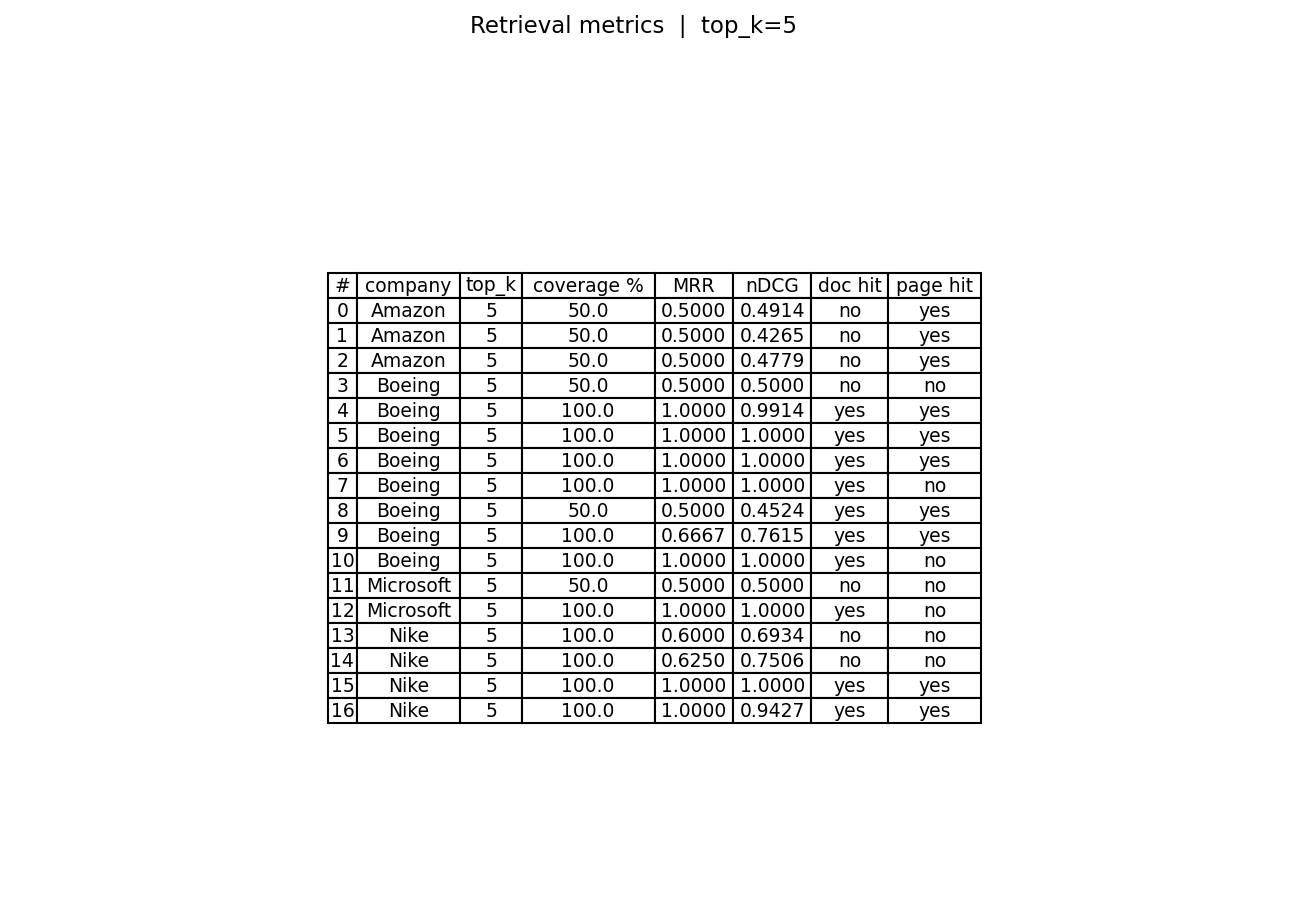

In [15]:
from evaluation.eval import run
from IPython.display import Image, display

eval_file = ROOT_DIR / "evaluation" / "financebench_open_source.jsonl"
plot_output = ROOT_DIR / "evaluation" / "results" / "k5_demo.png"

print("Iniciando avaliação do pipeline de retrieval...")
# Vamos rodar a avaliação demonstrando as questões solicitadas no case
run(jsonl_path=eval_file, max_tests=18, top_k=5, plot_file=plot_output)

# Vamos gerar um output gráfico para visualizar os resultados avaliativos
if plot_output.exists():
    display(Image(filename=str(plot_output)))
else:
    print("Gráfico não gerado")

Nota-se uma queda considerável nos scores onde os documentos referenciados por empresa e ano NÃO estão no apêndice utilizado (Data/pdfs), o que justifica o score e flutuações no score das métricas.

## 4. Interface Gradio
A interface visual construída com Gradio pode ser instanciada diretamente dentro do Jupyter Notebook, permitindo interagir com o agente sem precisar abrir o terminal.
A aplicação é interativa, logo pode-se acessar ao agente normalmente fazendo queries, testando a aplicação diretamente. 
toda a solução robusta está no diretório src.

In [11]:
import src.agent as agente_financeiro
from src.interface import build_gradio_app

# Construindo a aplicação Gradio
app = build_gradio_app(agente_financeiro)
app.launch(inline=True, share=True)

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
